# 🐶/😸 CIFAR-10 개/고양이 이진 분류 실습 (전이 학습)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, Subset
import os

## 1. 환경 설정 및 하이퍼파라미터 설정

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") #cuda 사용 여부에 따라 cuda인지 cpu인지 판단.
print(f"사용 중인 디바이스: {device}")

batch_size = 32 # 작은 값 유지.
learning_rate = 0.0001 # Pretrained 지식 보존을 위해 작은 값 사용

사용 중인 디바이스: cuda


## 2. 데이터 전처리 (Augmentation)

In [3]:
data_transforms = {# ImageNet 표준 정규화 값 적용
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),  # 무작위 크기 조절 및 크롭 #input image크기 224 // 다양하게 랜덤하게 잘라서 증강시킴.
        transforms.RandomHorizontalFlip(),     # 좌우 반전 // HorizontalFlip : 좌우 대칭
        transforms.ColorJitter(brightness=0.2, contrast=0.2),  # 밝기/대비 조절 #Color 지표
        transforms.ToTensor(), # 위의 3줄 증강하고 Tensor함.
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # ImageNet 통계값 [R,G,B 평균],[R,G,B 표준편차] #Image전체 사용했던거 RGB 표준편차 이용해서 정규화.
    ]),
    'val': transforms.Compose([  #train과 test 나눠서 함. val: validation
        transforms.Resize(256),
        transforms.CenterCrop(224), #Center을 기반으로 224 나눔. // 데이터증강 안했음. // validation이기 때문에 필요한 것 만들고 증강x
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

## 3. 데이터 로더 (DataLoader) 설정
CIFAR-10의 10개 클래스 중 3번(Cat)과 5번(Dog)만 골라내는 과정입니다.

* 10 클래스의 32x32 컬러 이미지 데이터 셋
* 각 클래스 당 5,000개 학습 이미지, 1,000개 테스트 이미지
* 비행기, 자동차, 새, **고양이**, 사슴, **개**, 개구리, 말, 배 및 트럭


-> 10개 중 다 필요x. 2개만 뽑아서 함.

In [4]:
full_train = datasets.CIFAR10(root='./data', train=True, download=True, transform=data_transforms['train'])
full_test = datasets.CIFAR10(root='./data', train=False, download=True, transform=data_transforms['val'])

print(f"CIFAR10 Train 데이터 개수: {len(full_train)}")
print(f"CIFAR10 Validation 데이터 개수: {len(full_test)}")

100%|██████████| 170M/170M [00:13<00:00, 12.5MB/s]


CIFAR10 Train 데이터 개수: 50000
CIFAR10 Validation 데이터 개수: 10000


In [5]:
# Cat(3), Dog(5) 인덱스만 추출하여 Subset 생성
def get_dog_cat_indices(dataset):
    return [i for i, (_, label) in enumerate(dataset) if label in [3, 5]] #데이터 3번이랑 5번만 추출.

train_indices = get_dog_cat_indices(full_train)
test_indices = get_dog_cat_indices(full_test)

print(f"Cat/Dog Train 데이터 개수: {len(train_indices)}")
print(f"Cat/Dog Validation 데이터 개수: {len(test_indices)}")

Cat/Dog Train 데이터 개수: 10000
Cat/Dog Validation 데이터 개수: 2000


In [6]:
# 라벨 재매핑 (3->0, 5->1)을 위한 Wrapper 클래스
class BinaryDataset(torch.utils.data.Dataset):
    def __init__(self, subset):
        self.subset = subset
    def __getitem__(self, index):
        x, y = self.subset[index]
        return x, (0 if y == 3 else 1) # Cat: 0, Dog: 1 #3으로 되어있는 건 0으로 바꿈.
    def __len__(self):
        return len(self.subset)

# 데이터셋 생성
image_datasets = {
    'train': BinaryDataset(Subset(full_train, train_indices)),
    'val': BinaryDataset(Subset(full_test, test_indices))
}

# 데이터 로더 설정
dataloaders = {
    'train': DataLoader(image_datasets['train'],  # DataLoader로 만들어줌.
                        batch_size=batch_size,
                        shuffle=True,
                        num_workers=4),
    'val': DataLoader(image_datasets['val'],  #32개로 batch_size.
                      batch_size=batch_size,
                      shuffle=False, # Validation set은 섞지 않음
                      num_workers=4) #num_workers : 병령처리. Colab에서 4로 지정해도 warning 뜰 수 있는데 무시하기.
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = ['cat', 'dog'] # 지금 0과 1로 되어있는데, 실제 이름으로 변경

print(f"Train 데이터 개수: {dataset_sizes['train']}")
print(f"Validation 데이터 개수: {dataset_sizes['val']}")

Train 데이터 개수: 10000
Validation 데이터 개수: 2000


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


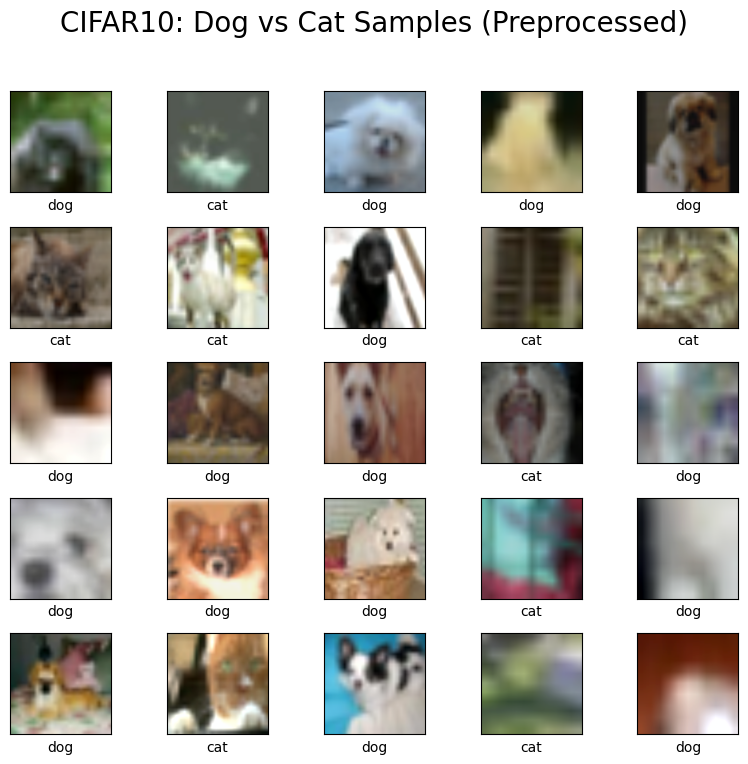

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# 학습 데이터셋에서 배치를 하나 가져옵니다
inputs, classes = next(iter(dataloaders['train']))

# 배치에서 25개의 이미지를 시각화합니다
plt.figure(figsize=(8, 8))
plt.suptitle('CIFAR10: Dog vs Cat Samples (Preprocessed)', fontsize=20)

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    # 이미지 시각화 : 역정규화 및 전치 처리가 포함된 imshow 호출
    img = inputs[i].numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])  # 색에 대한 정규화.
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean  #평균이랑 표준편차 사용해서 원래 이미지 돌아옴.
    img = np.clip(img, 0, 1)

    plt.imshow(img)
    plt.xlabel(class_names[classes[i]])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 4. 모델 불러오기 및 수정 (Fine-tuning 설정)

### 4-1) ResNet18

In [13]:
# (1) 미리 학습된 ResNet18 불러오기
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)  #1400만정도 가지고 있는 것으로.

# (2) [선택] 가중치 고정 (Feature Extraction)
# Backbone의 가중치를 고정하려면 아래 주석을 해제하세요
# for param in model.parameters():
#     param.requires_grad = False  #gradient에 의해 학습 시킬거니? 라는 의미.

# (3) 마지막 출력 레이어(FC Layer) 변경
# ResNet18의 원래 출력은 1000개 클래스 → 우리 클래스 수로 변경
num_ftrs = model.fc.in_features #fc: full connected
model.fc = nn.Linear(num_ftrs, len(class_names))  # 2개 클래스 (dog, cat) #len(class_names) = 2

model = model.to(device) #PYtorch는 cpu기반. gpu로 변환. -> gpu에서 실행하도록.
print(f"모델이 {device}로 이동되었습니다.")

모델이 cuda로 이동되었습니다.


### 4-2) EfficientNet-B0

In [12]:
# ResNet 대신 EfficientNet 사용하기
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

# 주의: EfficientNet은 마지막 레이어가 .classifier임
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, len(class_names))

model = model.to(device)
print(f"모델이 {device}로 이동되었습니다.")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 138MB/s]


모델이 cuda로 이동되었습니다.


## 5. 손실함수와 최적화 도구 설정

In [14]:
criterion = nn.CrossEntropyLoss()

# Fine-tuning 시에는 학습률을 아주 작게 설정 (보통 0.001 이하)
optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9) #최적화.

# 또는 Adam 옵티마이저 사용 (adaptive learning rate)
# optimizer = optim.Adam(model.parameters(), lr=learning_rate)

## 6. 학습 루프

In [15]:
def train_model(model, criterion, optimizer, num_epochs=10):
    for epoch in range(num_epochs): #epoch : 전체 데이터 몇 번 반복할것인지.
        print(f'Epoch {epoch+1}/{num_epochs}')

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # 학습 모드
            else:
                model.eval()   # 평가 모드

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

    return model

## 7. 학습 실행

In [16]:
model_ft = train_model(model, criterion, optimizer, num_epochs=3) #train 모델 3번만.

Epoch 1/3
train Loss: 0.6232 Acc: 0.6431
val Loss: 0.4709 Acc: 0.7880
Epoch 2/3
train Loss: 0.5208 Acc: 0.7300
val Loss: 0.3836 Acc: 0.8320
Epoch 3/3
train Loss: 0.4885 Acc: 0.7478
val Loss: 0.3418 Acc: 0.8520


## 모델 성능 검증

In [17]:
import time
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def evaluate_model(model, dataloader): #학습된 model에 대해서. evaluate함.
    model.eval()

    # 1. 정확도 및 리포트 출력
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs) #model에 대해 input받음.
            _, preds = torch.max(outputs, 1) #둘중에서 큰 것으로 보겠다.

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print("--- Classification Report ---")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # 2. 파라미터 수 측정
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"--- Model Complexity ---")
    print(f"Total Parameters: {total_params:,}")
    print(f"Trainable Parameters: {trainable_params:,}\n")

    # 3. FPS 측정 (Inference Speed)
    dummy_input = torch.randn(1, 3, 224, 224).to(device) #FPS 측정하기 위해 이미지 하나 넣어줌.
    # Warm-up
    for _ in range(10):
        _ = model(dummy_input)

    start_time = time.time()
    iterations = 100 #100번 반복해서 평균 계산.
    with torch.no_grad():
        for _ in range(iterations):
            _ = model(dummy_input)
    end_time = time.time()

    fps = iterations / (end_time - start_time)
    print(f"--- Inference Performance ---")
    print(f"FPS (Frames Per Second): {fps:.2f} on {device}\n") #초당 __개 처리해줌.

# 검증 데이터셋으로 성능 평가 실행
evaluate_model(model_ft, dataloaders['val'])

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


--- Classification Report ---
              precision    recall  f1-score   support

         cat       0.85      0.86      0.85      1000
         dog       0.86      0.85      0.85      1000

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000

--- Model Complexity ---
Total Parameters: 11,177,538
Trainable Parameters: 11,177,538

--- Inference Performance ---
FPS (Frames Per Second): 345.93 on cuda



## 8. 모델 저장

In [19]:
torch.save(model_ft.state_dict(), 'resnet18_dogs_vs_cats.pth') #모델 추가로 더 사용하고 싶으면, 저장함. -> 파일 저장 (확장자는 pth)